In [1]:
from os.path import dirname, abspath,join
from os import makedirs, listdir
import sys
import numpy as np
import pandas as pd
import json
import re
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

root_path = dirname(abspath("./"))
import sys
sys.path.append(root_path)
from causaliT.evaluation.predict import *
from causaliT.evaluation.eval_sweeps import *
from causaliT.training.forecasters.transformer_forecaster import TransformerForecaster
from notebooks.lib import *
from eval_fun import eval_interventions

# plotting standard settings
plt.rcParams['figure.dpi'] = 100 #360 # standard is 360 but for set to 100 for practical visualization on the notebook
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['lines.linewidth'] = 1.5

datadir_path = r"../data/"

In [2]:
experiments = [
        (r"../experiments/report/euler/stage_SoftMax_scm6_54604038", "SoftMax no DAG"),
        (r"../experiments/report/euler/stage_SoftMax_hard_scm6_54603903", "SoftMax with true DAG"),
    ]

df_list = []
df_dev_list = []
for exp_path, exp_label in experiments:
    df_exp, df_dev_exp = eval_interventions(exp_path)
    df_exp["experiment"] = exp_label
    df_dev_exp["experiment"] = exp_label
    df_list.append(df_exp)
    df_dev_list.append(df_dev_exp)
    
df = pd.concat(df_list, axis=0)
df_dev = pd.concat(df_dev_list, axis=0)

Experiment already available. Data loaded!
Saved summary: do_summary.csv
Experiment already available. Data loaded!
Saved summary: do_summary.csv


Text(0.5, 0, "$\\Delta Y_2 | S_2=s' $")

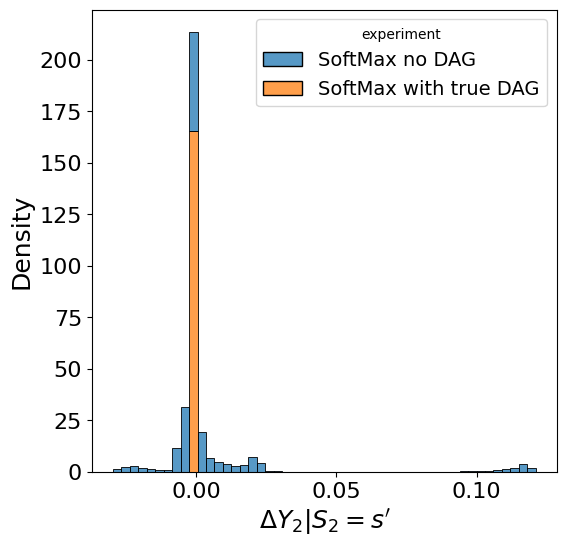

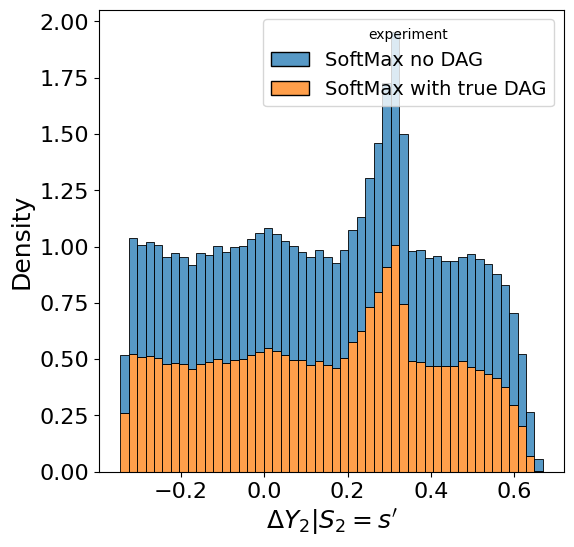

In [3]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index("intervention").loc[["S1=0","S1=1", "S1=-1"]].set_index("trg_feat_1").loc[7.0], x="pred_feat_0", hue="experiment", ax=ax, stat="density", multiple="stack", bins=50)
# ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_xlabel(r"$\Delta Y_2 | S_2=s' $")

fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index("intervention").loc[["S2=0","S2=1", "S2=-1"]].set_index("trg_feat_1").loc[7.0], x="pred_feat_0", hue="experiment", ax=ax, stat="density", multiple="stack", bins=50)
# ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_xlabel(r"$\Delta Y_2 | S_2=s' $")

# CausaliT

## SCM 6 - Linear Gaussian

In [4]:
experiments = [
        (r"../experiments/single/local/single_Lie_CC_scm6_loc001", "CausaliT"),
        (r"../experiments/single/euler/single_SM_SM_scm6_54946380", "SoftMax"),
    ]

df_list = []
df_dev_list = []
for exp_path, exp_label in experiments:
    df_exp, df_dev_exp = eval_interventions(exp_path)
    df_exp["experiment"] = exp_label
    df_dev_exp["experiment"] = exp_label
    df_list.append(df_exp)
    df_dev_list.append(df_dev_exp)
    
df = pd.concat(df_list, axis=0)
df_dev = pd.concat(df_dev_list, axis=0)

Experiment already available. Data loaded!
Saved summary: do_summary.csv
Experiment already available. Data loaded!
Saved summary: do_summary.csv


Text(0.5, 1.0, 'CausaliT')

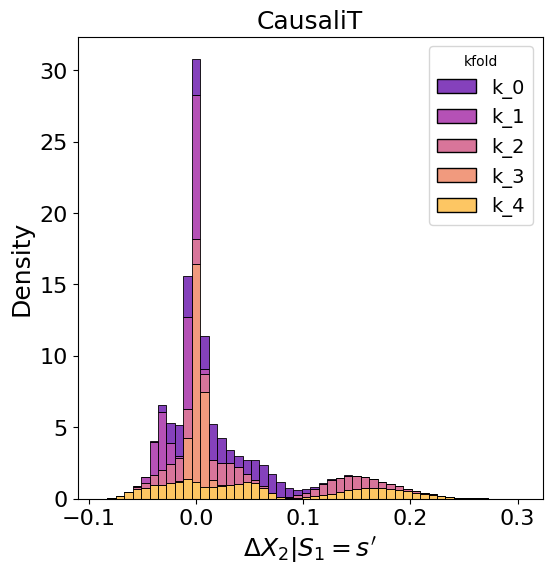

In [57]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index(["experiment","intervention"]).loc["CausaliT"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", hue="kfold", ax=ax, stat="density", bins=50, multiple="stack", palette="plasma")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel(r"$\Delta X_2 | S_1=s'$")
ax.set_title("CausaliT")

Text(0.5, 1.0, 'SoftMax')

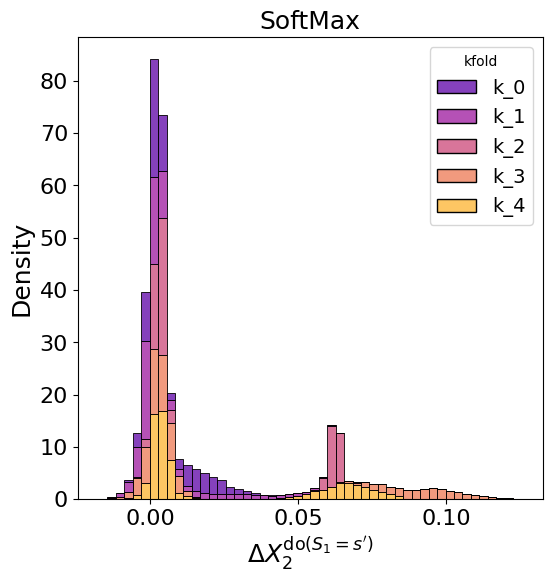

In [49]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index(["experiment","intervention"]).loc["SoftMax"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", hue="kfold", ax=ax, stat="density", bins=50, multiple="stack", palette="plasma")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel(r"$\Delta X_2^{\text{do}(S_1=s')}$")
ax.set_title("SoftMax")

Text(0.5, 1.0, 'Best Folds')

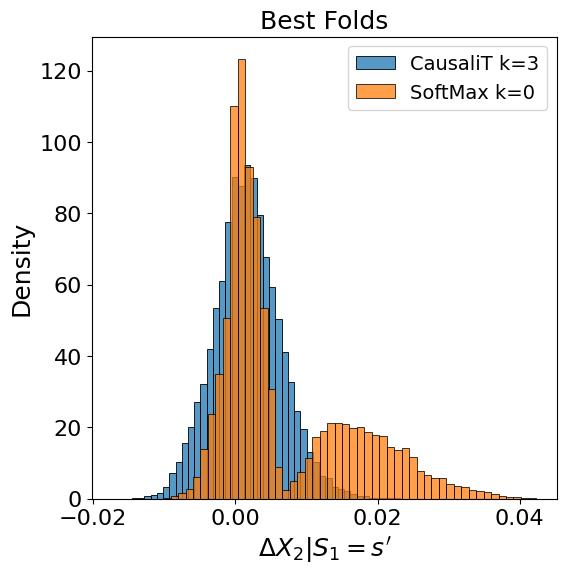

In [59]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index(["experiment","kfold","intervention"]).loc["CausaliT"].loc["k_3"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", ax=ax, stat="density", bins=50, multiple="stack",label="CausaliT k=3")
sns.histplot(data=df_dev.set_index(["experiment","kfold","intervention"]).loc["SoftMax"].loc["k_0"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", ax=ax, stat="density", bins=50, multiple="stack", label="SoftMax k=0")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.legend()
ax.set_xlabel(r"$\Delta X_2 | S_1=s'$")
ax.set_title("Best Folds")

Text(0.5, 1.0, 'All Folds')

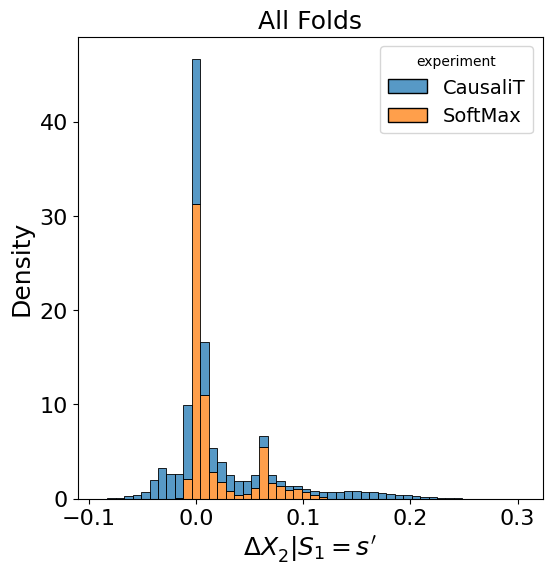

In [60]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index("intervention").loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", hue="experiment", ax=ax, stat="density", bins=50, multiple="stack")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel(r"$\Delta X_2^ | S_1=s'$")
ax.set_title("All Folds")

## SCM 7 - Non-linear Gaussian

In [5]:
experiments = [
        (r"../experiments/single/euler/single_Lie_CC_scm7_55058272", "CausaliT"),
        (r"../experiments/single/euler/single_SM_SM_scm7_55058353", "SoftMax"),
    ]

df_list = []
df_dev_list = []
for exp_path, exp_label in experiments:
    df_exp, df_dev_exp = eval_interventions(exp_path)
    df_exp["experiment"] = exp_label
    df_dev_exp["experiment"] = exp_label
    df_list.append(df_exp)
    df_dev_list.append(df_dev_exp)
    
df = pd.concat(df_list, axis=0)
df_dev = pd.concat(df_dev_list, axis=0)

Experiment already available. Data loaded!
Saved summary: do_summary.csv
Experiment already available. Data loaded!
Saved summary: do_summary.csv


Text(0.5, 1.0, 'CausaliT')

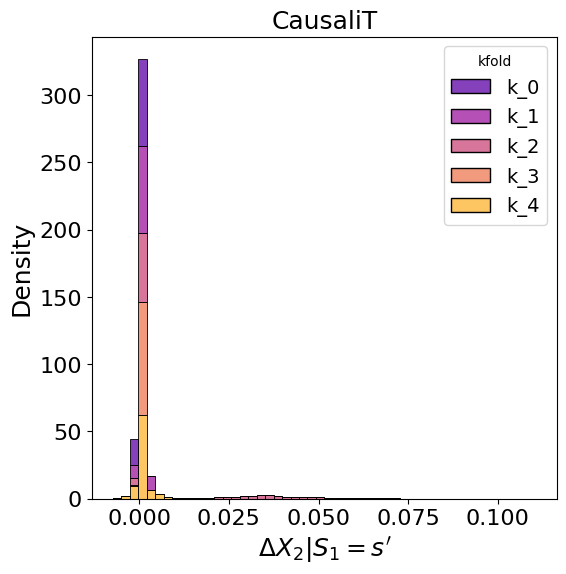

In [64]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index(["experiment","intervention"]).loc["CausaliT"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", hue="kfold", ax=ax, stat="density", bins=50, multiple="stack", palette="plasma")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel(r"$\Delta X_2 | S_1=s'$")
ax.set_title("CausaliT")

Text(0.5, 1.0, 'SoftMax')

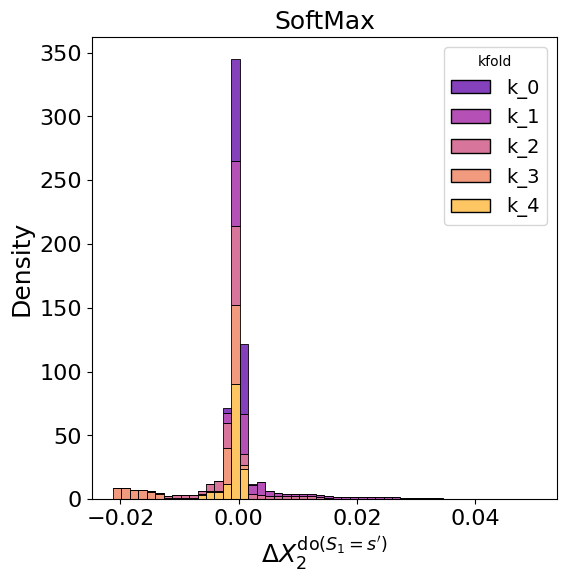

In [65]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index(["experiment","intervention"]).loc["SoftMax"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", hue="kfold", ax=ax, stat="density", bins=50, multiple="stack", palette="plasma")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel(r"$\Delta X_2^{\text{do}(S_1=s')}$")
ax.set_title("SoftMax")

Text(0.5, 1.0, 'Best Folds')

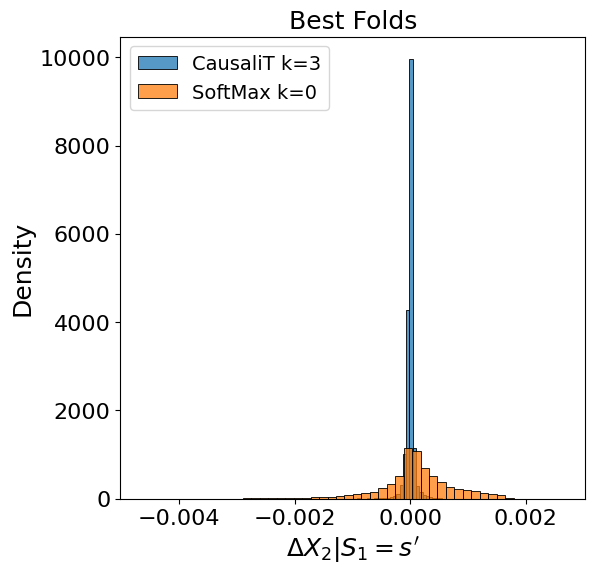

In [66]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index(["experiment","kfold","intervention"]).loc["CausaliT"].loc["k_3"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", ax=ax, stat="density", bins=50, multiple="stack",label="CausaliT k=3")
sns.histplot(data=df_dev.set_index(["experiment","kfold","intervention"]).loc["SoftMax"].loc["k_0"].loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", ax=ax, stat="density", bins=50, multiple="stack", label="SoftMax k=0")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.legend()
ax.set_xlabel(r"$\Delta X_2 | S_1=s'$")
ax.set_title("Best Folds")

Text(0.5, 1.0, 'All Folds')

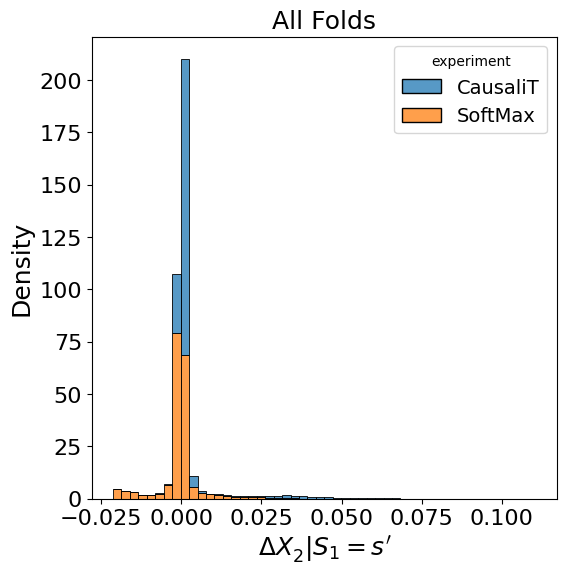

In [63]:
fig, ax = plt.subplots()
sns.histplot(data=df_dev.set_index("intervention").loc[["S1=0", "S1=1", "S1=-1"]].set_index("trg_feat_1").loc[5.0], x="pred_feat_0", hue="experiment", ax=ax, stat="density", bins=50, multiple="stack")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel(r"$\Delta X_2^ | S_1=s'$")
ax.set_title("All Folds")